In [1]:
%matplotlib widget
import numpy as np
import k3d
import matplotlib.pyplot as plt
from sloppy.optic import *
from sloppy.raytracing import *
from sloppy.abcd import *
from sloppy.utils import *
from sloppy.tools import *

In [36]:
def rgb2hex(r,g,b):
    return "0x{:02x}{:02x}{:02x}".format(r,g,b)

import matplotlib.colors as col
from colorspacious import cspace_convert
import matplotlib.patches as patches
from matplotlib import colors
# Generate the cyclic colormap
color_circle = np.ones((256, 3)) * 60
color_circle[:, 1] = np.ones((256)) * 45
color_circle[:, 2] = np.arange(0, 360, 360 / 256)
color_circle_rgb = cspace_convert(color_circle, "JCh", "sRGB1")
cm = col.ListedColormap(color_circle_rgb)

In [29]:
def LensCavAsphere(arm1=42., arm2=21., base=17., angle=110., lens_dist=24.47, Rlens=5.0, c4=coeffc4(5.0), c6=coeffc6(5.0), c8=coeffc8(5.0)):
    angle = np.deg2rad(angle)
    lens_diam=6.35
    lens_thick=4.
    p0 = np.array([lens_dist/2.-lens_thick/2.,0,0])
    p1 = np.array([lens_dist/2.+lens_thick/2.,0,0])
    p2 = np.array([arm1/2.,0,0])
    p3 = np.array([np.cos(angle)*arm2/2.,base,np.sin(angle)*arm2/2.])
    p4 = np.array([-np.cos(angle)*arm2/2.,base,-np.sin(angle)*arm2/2.])
    p5 = np.array([-arm1/2.,0,0])
    p6 = np.array([-lens_dist/2.-lens_thick/2.,0,0])
    p7 = np.array([-lens_dist/2.+lens_thick/2.,0,0])
    ps = np.stack([p0,p1,p2,p3,p4,p5,p6,p7], axis=0)
    
    geom = geometry(ps)
    ns = geom['refl']
    ps = geom['mir']
    angles = geom['angles']
    Rtr = geom['R']
    ax_x = geom['xin']
    ax_y = np.cross(ns, ax_x)
        
    hi = 12.7
    qi=7.75
    ng = 1.4537
    
    coef = np.zeros(9)
    coef[2] = coeffc2(Rlens)
    coef[4] = c4
    coef[6] = c6
    coef[8] = c8
     #negative sign of firstt cuved surface for abcd matrix
    elements = [Glass(p=ps[0], n=ns[0], ax=ax_x[0], ay=ax_y[0], Rbasis=Rtr[0], diameter=lens_diam, n2=ng),\
                FreeFormInterface(p=ps[1], n=ns[1], ax=ax_x[1], ay=ax_y[1], Rbasis=Rtr[1], diameter=lens_diam, n1=ng, coef=coef),\
                Mirror(p=ps[2], n=ns[2], ax=ax_x[2], ay=ax_y[2], Rbasis=Rtr[2], diameter=hi),\
                Mirror(p=ps[3], n=ns[3], ax=ax_x[3], ay=ax_y[3], Rbasis=Rtr[3], diameter=hi),\
                Mirror(p=ps[4], n=ns[4], ax=ax_x[4], ay=ax_y[4], Rbasis=Rtr[4], diameter=hi),\
                Mirror(p=ps[5], n=ns[5], ax=ax_x[5], ay=ax_y[5], Rbasis=Rtr[5], diameter=hi),\
                FreeFormInterface(p=ps[6], n=ns[6], ax=ax_x[6], ay=ax_y[6], Rbasis=Rtr[6], diameter=lens_diam, n2=ng, coef=-coef),\
                Glass(p=ps[7], n=ns[7], ax=ax_x[7], ay=ax_y[7], Rbasis=Rtr[7], diameter=lens_diam, n1=ng),
                Screen(p=np.array([0,0,0]), n=np.array([1,0,0]), ax=-ax_x[0], ay=ax_y[0], diameter=lens_diam),]
    return elements


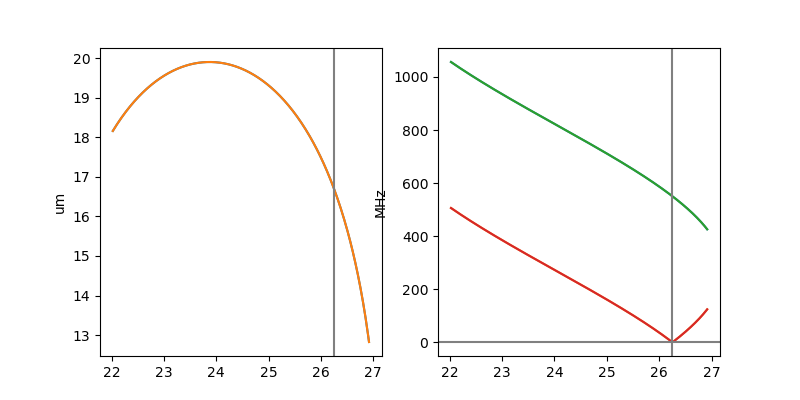

26.245916387959866

In [68]:
waists_vs_param(LensCavAsphere, 'lens_dist', 10e-2, s=1, degmodenum=2)

In [69]:
res = degeneracy_length(LensCavAsphere, 'lens_dist', 20e-2, s=1, degmodenum=2)
Ldeg = 26.245 #res.x
print(res)

 message: Solution found.
 success: True
  status: 0
     fun: 17887.07506501672
       x: 26.25394417458741
     nit: 13
    nfev: 13


In [75]:
elements = LensCavAsphere(lens_dist=Ldeg)
sys = RaySystem(elements, add_screen=True)
# sys.screen = sys.elements[0]

In [76]:
system = sys.abcd
print(system.Ltot)
system.waist_at(0)
mu1, mu2 = system.q
screen = sys.screen

125.96287424209984


In [85]:
mu = 0.0*np.real(mu1) + 0.1*np.real(mu2) 
ray = sys.screen.eigenvectors_to_rays(mu)
Nrt = 20
traj = sys.propagate(ray, Nrt=20)

In [86]:
try:
    plot.close()
except:
    pass
plot = k3d.plot(camera_auto_fit=True, antialias=True)

for i, el in enumerate(sys.elements[:-1]):
    plot += el.plot(opacity=0.4)

plot += screen.plot(opacity=0.4)

# cm = plt.get_cmap('magma')


lt = (traj.shape[0]-1)//Nrt
for i, c in enumerate(np.linspace(0, 1, Nrt)):
    rgba = cm(c)
    rgb = (np.array(rgba[:-1])*255).astype(int)
    color = int(rgb2hex(*rgb), base=16)
    plot_trajs(traj[i*lt:(i+1)*lt+1], plot, shader='thick', width=0.1, color=color, )
    # plot_trajs(traj, plot, shader='thick', width=0.1, color=color, )
plot.display()

/Users/lukas/anaconda3/envs/sloppy/lib/python3.12/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float64" does not match required type "float32". A coerced copy has been created.
  warnings.warn(


Output()

In [93]:
with open('raytrace_lg1_thin.html', 'w') as f:
    # f.write(plot.get_snapshot())
    f.write(plot.get_snapshot(additional_js_code='K3DInstance.startAutoPlay()'))

In [74]:
with open("rays_lg_1.html", 'w') as f:
    f.write(plot.get_snapshot())

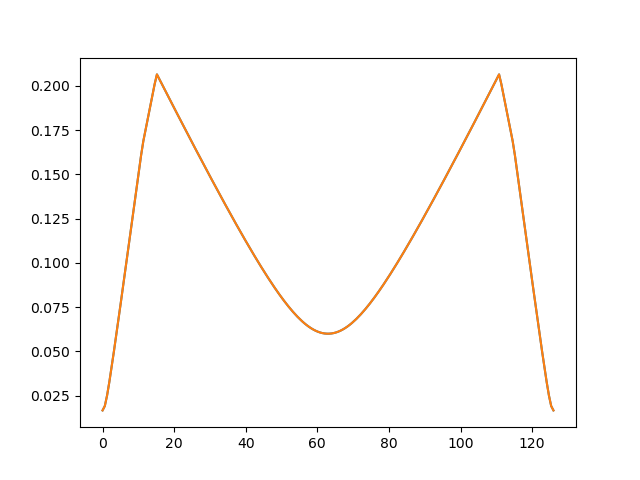

In [56]:
x = np.linspace(0, system.Ltot, 200)
ws = system.compute_waists(x)

plt.figure()
plt.plot(x, ws)

In [33]:
np.trace(system.abcd_rt)/2

0.32532553256705066

In [66]:
x, y = disc_coords(R=0.1, n_radii=3, n_angles=3.)
mu = np.stack([x, y, np.zeros_like(x), np.zeros_like(y)], axis=1)
rayf = sys.screen.eigenvectors_to_rays(mu)
traj_hit = sys.propagate(rayf)

ZeroDivisionError: division by zero

In [57]:
#turn the paraxial eigenrays (eigenvectors of ABCD matrix) into rays (position and slope three-vectors for raytracing)
mu = np.array([1e-1, 0., 0, 0.])
ray1 = sys.screen.eigenvectors_to_rays(mu)
traj_hit = sys.propagate(ray1, Nrt=1)

In [59]:
plot = k3d.plot(camera_auto_fit=True, antialias=True)

for i, el in enumerate(sys.elements):
    plot += el.plot(opacity=0.4)
    
for i, el in enumerate(sys.elements):
    plot_element_ax(el, plot, length=2.)

plot_rays(ray, plot, length=3.)
#plot_trajs(traj, plot)
plot_trajs(traj_hit, plot, shader='mesh', width=0.15, color=0xff5733)
# plot_trajs(traj_hit[0:4,...], plot, color=0xff5733)
plot.display()

Output()

In [60]:
#turn the paraxial eigenrays (eigenvectors of ABCD matrix) into rays (position and slope three-vectors for raytracing)
mu = np.array([0, 0., 1e-4, 0.])
ray1 = sys.screen.eigenvectors_to_rays(mu)
traj_hit = sys.propagate(ray1, Nrt=500, at_screen=True)

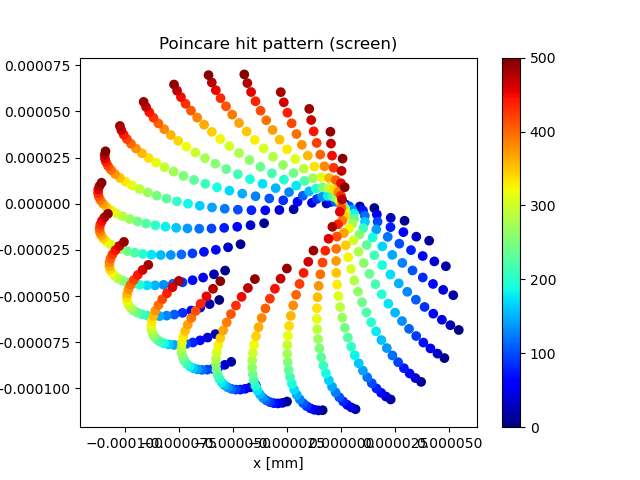

In [61]:
hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])

def makeidx(hit_m):
    return np.arange(hit_m.shape[0])

plt.figure()
line = plt.scatter(hit_scr[:,0], hit_scr[:,1], c=makeidx(hit_scr), cmap='jet')
plt.title('Poincare hit pattern (screen)')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.colorbar()
plt.show()

In [62]:
%matplotlib widget
from ipywidgets import *

interactive(children=(FloatSlider(value=26.245, description='lens_dist', max=26.255000000000003, min=26.235, s…

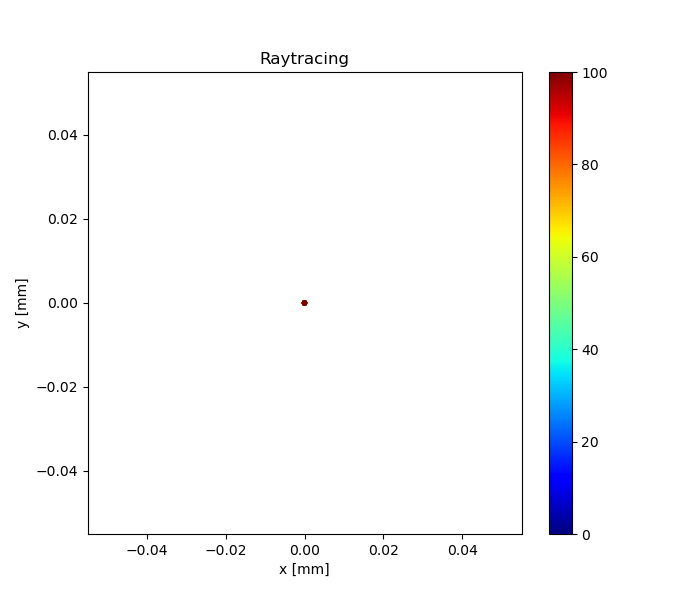

In [63]:
fig, ax = plt.subplots(ncols=1, figsize=(7, 6))
ms = 8.
linea = ax.scatter(hit_scr[:,0], hit_scr[:,1], c=makeidx(hit_scr), cmap='jet', s=ms)
ax.set_title('Raytracing')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
#plt.xlim(-2, 2)
#plt.ylim(-2, 2)
plt.colorbar(linea)
#0.1, 0., 1e-2, -1e-3
def update(lens_dist=Ldeg, x=0., y=0.0, px=1e-4, py=0., Nrt=100, **kwargs):
    elements= LensCavAsphere(lens_dist=lens_dist)
    sys = RaySystem(elements)
    #print(geom['Lrt'])
    mu = np.array([x, y, px, py])*1e-2
    ray = sys.screen.eigenvectors_to_rays(mu)
    #ray[1,:,:] *= -1
    
    traj_hit = sys.propagate(ray, Nrt=Nrt, at_screen=True)
    hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])

    linea.set_offsets(hit_scr[:,:])
    linea.set_array(makeidx(hit_scr))

    linea.set_clim(vmin=0, vmax=Nrt)     
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()
        
#interactive(update, dl=(27.2, 27.9, 1e-2), ar = (0,0.1,1e-3), br = (0,0.1,1e-3), ap= (0,2*np.pi,1e-2), bp= (0,2*np.pi,1e-2), Nrt=(0,2000,100))
interactive(update, lens_dist=(Ldeg-1e-2, Ldeg+1e-2, 1e-3), x = (-0.1,0.1,1e-3), y = (-0.1,0.1,1e-3), px=(-0.1,0.1,1e-3), py=(-0.1,0.1,1e-3), Nrt=(0,2000,100))

 message: Solution found.
 success: True
  status: 0
     fun: 17887.07506501672
       x: 26.25394417458741
     nit: 13
    nfev: 13


interactive(children=(FloatSlider(value=0.0, description='dl', layout=Layout(width='90%'), max=1.0, min=-10.0,…

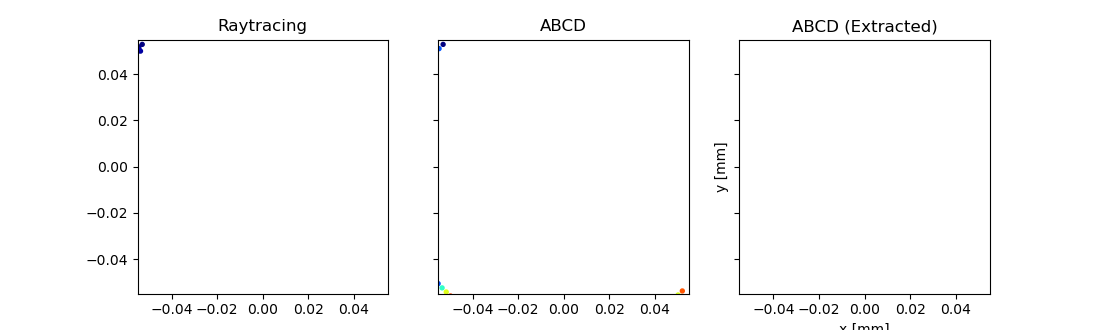

In [72]:
from ipywidgets import FloatSlider, Layout, Box

fig, (ax, bx, cx) = plt.subplots(ncols=3, figsize=(11,3.3), sharex=True, sharey=True)
ms = 8.
linea = ax.scatter([], [], c=[], cmap='jet', s=ms)
linec = cx.scatter([], [], c=[], cmap='jet', s=ms)
lineb = bx.scatter([], [], c=[], cmap='jet', s=ms)
ax.set_title('Raytracing')
bx.set_title('ABCD')
cx.set_title('ABCD (Extracted)')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
 
cavfct = LensCavAsphere
parname = 'lens_dist'
res = degeneracy_length(cavfct, 'lens_dist', 20e-2, s=1, degmodenum=2)
Ldeg = res.x
print(res)

def makeidx(hit_m):
    return np.arange(hit_m.shape[0])

def update(dl=0., ar=0.0001, br=0.0, ap=0., bp=0., Nrt=500, **kwargs):
        elements = cavfct(**{parname: Ldeg+dl*1e-1})
        sys = RaySystem(elements)
        system = sys.abcd
        mu1, mu2 = system.q

        mu = np.real(ar*np.exp(1j*ap)*mu1 + br*np.exp(1j*bp)*mu2)
        ray0 = sys.screen.eigenvectors_to_rays(mu)
 
        traj_hit = sys.propagate(ray0, Nrt=Nrt, at_screen=True)
        hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])

        linea.set_offsets(hit_scr[:,:])
        linea.set_array(makeidx(hit_scr))
        
        hit_m = propagate_ABCD(mu, system.abcd_rt, Nrt=Nrt)
        lineb.set_offsets(hit_m[:,0:2])
        lineb.set_array(makeidx(hit_m))
        
        # abcd_fd = sys.extract_ABCD(epsr=1e-3, epss=1e-3, Nrt=1) 
        # hit_fd = propagate_ABCD(mu, abcd_fd, Nrt=Nrt)
        # linec.set_offsets(hit_fd[:,0:2])
        # linec.set_array(makeidx(hit_fd))
        
        linea.set_clim(vmin=0, vmax=Nrt)
        lineb.set_clim(vmin=0, vmax=Nrt)
        linec.set_clim(vmin=0, vmax=Nrt)
            
        ax.relim(visible_only=True)
        ax.autoscale_view(tight=True)
        fig.canvas.draw_idle()
        
#interactive(update, dl=(-10, 1, 1e-3), ar = (0,0.1,1e-3), br = (0,0.5,1e-3), ap= (0,2*np.pi,1e-2), bp= (0,2*np.pi,1e-2), Nrt=(0,2000,100))
layout = Layout(width='90%')
#items_layout = Layout( width='auto')     # override the default width of the button to 'auto' to let the button grow
#layout = Layout(display='flex',
#                    flex_flow='column',
#                    align_items='stretch',
#                    width='80%')

dls = FloatSlider(value=0., min=-10, max=1, step=1e-3, readout_format='.3f', layout=layout)
ars = FloatSlider(value=0.1, min=0, max=0.5, step=1e-3, readout_format='.3f', layout=layout)
brs = FloatSlider(value=0., min=0, max=0.5, step=1e-3, readout_format='.3f', layout=layout)
aps = FloatSlider(value=0., min=0, max=2*np.pi, step=1e-2, readout_format='.3f', layout=layout)
bps = FloatSlider(value=0., min=0, max=2*np.pi, step=1e-2, readout_format='.3f', layout=layout)
Nrts = IntSlider(value=100, min=0, max=5000, step=10, readout_format='.3f', layout=layout)
interactive(update, dl=dls, ar=ars, br=brs, ap=aps, bp=bps, Nrt=Nrts)

NameError: name 'LensCavNewGeom' is not defined

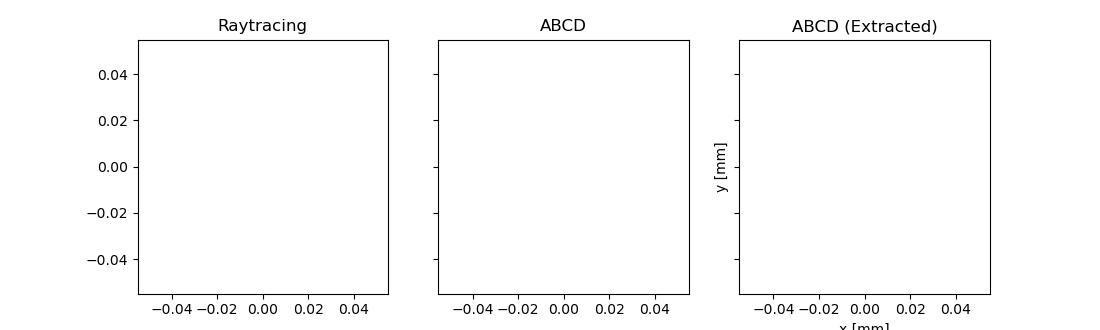

In [19]:
fig, (ax, bx, cx) = plt.subplots(ncols=3, figsize=(11,3.3), sharex=True, sharey=True)
ms = 8.
linea = ax.scatter([], [], c=[], cmap='jet', s=ms)
linec = cx.scatter([], [], c=[], cmap='jet', s=ms)
lineb = bx.scatter([], [], c=[], cmap='jet', s=ms)
ax.set_title('Raytracing')
bx.set_title('ABCD')
cx.set_title('ABCD (Extracted)')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
 
cavfct = LensCavNewGeom
parname = 'lens_dist'
res = degeneracy_length(cavfct, parname, 1e-3)
Ldeg = res.x
print(res)

def makeidx(hit_m):
    return np.arange(hit_m.shape[0])

def update(dl=0., ar=0.0001, br=0.0, ap=0., bp=0., Nrt=500, **kwargs):
        elements = cavfct(**{parname: Ldeg+dl*1e-1})
        sys = RaySystem(elements)
        system = sys.abcd
        mu1, mu2 = system.q

        mu = np.real(ar*np.exp(1j*ap)*mu1 + br*np.exp(1j*bp)*mu2)
        ray0 = sys.screen.eigenvectors_to_rays(mu)
 
        traj_hit = sys.propagate(ray0, Nrt=Nrt, at_screen=True)
        hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])

        linea.set_offsets(hit_scr[:,:])
        linea.set_array(makeidx(hit_scr))
        
        hit_m = propagate_ABCD(mu, system.abcd_rt, Nrt=Nrt)
        lineb.set_offsets(hit_m[:,0:2])
        lineb.set_array(makeidx(hit_m))
        
        abcd_fd = sys.extract_ABCD(epsr=1e-3, epss=1e-3, Nrt=1) 
        hit_fd = propagate_ABCD(mu, abcd_fd, Nrt=Nrt)
        linec.set_offsets(hit_fd[:,0:2])
        linec.set_array(makeidx(hit_fd))
        
        linea.set_clim(vmin=0, vmax=Nrt)
        lineb.set_clim(vmin=0, vmax=Nrt)
        linec.set_clim(vmin=0, vmax=Nrt)
            
        ax.relim(visible_only=True)
        ax.autoscale_view(tight=True)
        fig.canvas.draw_idle()
        
interactive(update, dl=(-10, 1, 1e-3), ar = (0,0.1,1e-3), br = (0,0.5,1e-3), ap= (0,2*np.pi,1e-2), bp= (0,2*np.pi,1e-2), Nrt=(0,2000,100))

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
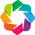

In [20]:
import pandas as pd
import datashader as ds
import panel as pn
import holoviews as hv
import holoviews.operation.datashader as hd
from datashader import transfer_functions as tf
from colorcet import palette_n
from bokeh.plotting import show
from matplotlib.cm import viridis

hv.extension('bokeh')
pn.extension()
ps = {k:p[::-1] for k,p in palette_n.items()}

In [21]:
Ldeg = 27.768298126226423

def ray_trajectories(dl=Ldeg, dz=1.5825, x=0.01, y=0.0, px=0., py=0., Nrt=500, **kwargs):
    elements, _ = SixMirror(dx=dl, dzF=dz)
    sys = RaySystem(elements)
    mu = np.array([x, y, px, py])
    ray = sys.screen.eigenvectors_to_rays(mu)

    traj_hit = sys.propagate(ray, Nrt=Nrt, at_screen=True)
    hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])
    return hit_scr[:,0], hit_scr[:,1]

In [22]:
scale = 100.
def ray_plot(dl=Ldeg*scale, dlf=0., dz=1.5825*scale, x=0.0, y=0.0, px=0., py=0., n=3., cmap=ps['kbc'], **kwargs):
    Nrt = int(10**n)
    cvs = ds.Canvas(plot_width=600, plot_height=600)
    xs, ys = ray_trajectories(dl/scale+dlf/scale/10., dz/scale, x/scale, y/scale, px/scale, py/scale, Nrt)
    df = pd.DataFrame(dict(x=xs,y=ys))
    agg = cvs.points(df, 'x', 'y')
    img = tf.shade(agg, cmap=viridis)
    return tf.spread(img, px=2, name="spread 1px")

In [23]:
pane = pn.interact(ray_plot, dl=(Ldeg*scale-3, Ldeg*scale+3, 1e-2, Ldeg*scale), dlf = (-0.1,0.1,1e-3), dz=(0, 1.5825*scale, 1e-2), x = (-0.1,0.1,1e-3), y = (-0.1,0.1,1e-3),\
                   px=(-0.1,0.1,1e-3), py=(-0.1,0.1,1e-3), n=(2.0, 7.0, 0.1, 3.0), cmap=ps)
text = """bla..."""

pn.Row(pn.Column(text, pane[0]), pane[1])

ValueError: too many values to unpack (expected 2)

In [24]:
scale=100.
def ray_trajectories2(dl=51.0, thet=20., axi=51.0, x=0.0, y=0.0, px=0., py=0., Nrt=500, **kwargs):
    elements, _ = GravEM(l=dl, theta=np.deg2rad(thet), axialL00=axi)
    sys = RaySystem(elements)
    mu = np.array([x, y, px, py])
    ray = sys.screen.eigenvectors_to_rays(mu)

    traj_hit = sys.propagate(ray, Nrt=Nrt, at_screen=True)
    hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])
    return hit_scr[:,0], hit_scr[:,1]

def ray_plot2(dl=51.0*scale, dlf=0., thet=20., axi=51.0*scale, x=0.0, y=0.0, px=0., py=0., n=3.,  **kwargs):
    Nrt = int(10**n)
    cvs = ds.Canvas(plot_width=600, plot_height=600)
    xs, ys = ray_trajectories2(dl/scale+dlf/scale/10., thet, 51., x/scale, y/scale, px/scale, py/scale, Nrt)
    df = pd.DataFrame(dict(x=xs,y=ys))
    agg = cvs.points(df, 'x', 'y')
    img = tf.shade(agg, cmap=viridis)
    return tf.spread(img, px=2, name="spread 1px")

In [25]:
pane = pn.interact(ray_plot2, dl=(51.*scale-3, 51.*scale+3, 1e-2, 51.*scale), dlf = (-0.1,0.1,1e-3), thet=(10, 25., 1e-2),\
                   axi = (51.*scale-3, 51.*scale+3, 1e-2, 51*scale), x = (-0.1,0.1,1e-3), y = (-0.1,0.1,1e-3),\
                   px=(-0.1,0.1,1e-3), py=(-0.1,0.1,1e-3), n=(2.0, 7.0, 0.1, 3.0))
text = """bla..."""

pn.Row(pn.Column(text, pane[0]), pane[1])

ValueError: too many values to unpack (expected 2)

interactive(children=(FloatSlider(value=50.0, description='arm1', max=60.0, min=30.0), FloatSlider(value=55.0,…

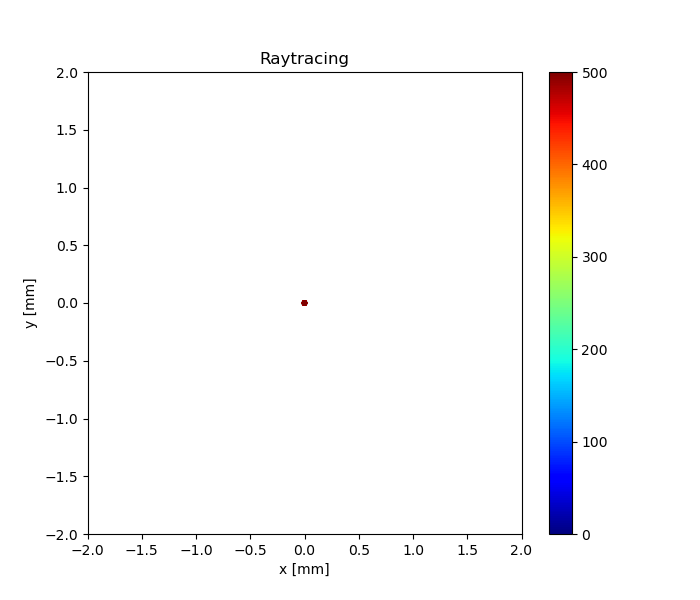

In [26]:
fig, ax = plt.subplots(ncols=1, figsize=(7, 6))
ms = 8.
linea = ax.scatter(hit_scr[:,0], hit_scr[:,1], c=makeidx(hit_scr), cmap='jet', s=ms)
ax.set_title('Raytracing')
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.colorbar(linea)
#0.1, 0., 1e-2, -1e-3
def update(arm1=50., arm2=55., base=19., ang=150., lens_dist=23.5, x=0., y=0.0, px=0., py=0., Nrt=100, **kwargs):
    elements= LensCavNewGeom(arm1=arm1, arm2=arm2, base=base, angle=np.deg2rad(ang), lens_dist=lens_dist)
    sys = RaySystem(elements)
    #print(geom['Lrt'])
    mu = np.array([x, y, px, py])
    ray = sys.screen.eigenvectors_to_rays(mu)
    ray[1,:,:] *= -1
    
    traj_hit = sys.propagate(ray, Nrt=Nrt, at_screen=True)
    hit_scr = sys.screen.r_to_screen_coords(traj_hit[:,0,0,:])

    linea.set_offsets(hit_scr[:,:])
    linea.set_array(makeidx(hit_scr))

    linea.set_clim(vmin=0, vmax=Nrt)     
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()
        
#interactive(update, dl=(27.2, 27.9, 1e-2), ar = (0,0.1,1e-3), br = (0,0.1,1e-3), ap= (0,2*np.pi,1e-2), bp= (0,2*np.pi,1e-2), Nrt=(0,2000,100))
interactive(update, arm1=(30., 60., 0.1), arm2=(30., 60., 0.1), base=(15., 25., 0.1), lens_dist=(22., 25., 1e-3), \
            ang=(0., 180., 1.), x = (0,0.1,1e-3), y = (0,0.1,1e-3), px=(-0.1,0.1,1e-3), py=(-0.1,0.1,1e-3), Nrt=(0,2000,100))